# Integral vs. $R$

We want to evaluate

$$
I(R)=\int_{Y_0}^{Y_1}\int_{X_0}^{X_1}\int_0^Z \frac{z}{\left(\left(z^2+x^2+y^2\right)\left(\left(R-x\right)^2+y^2+Z^2\right)\right)^{3/2}}\,dz\,dx\,dy
$$

with

$$
Y_0=m_y-25,\quad Y_1=25-m_y,\quad X_0=m_x-25,\quad X_1=25-m_x,
$$

and the specific values

$$
m_x=0,\quad m_y=0,\quad Z=2.
$$

So in this notebook the integration region is the square

$$
-25 \le x \le 25,\qquad -25 \le y \le 25.
$$


In [1]:
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm

plt.style.use("seaborn-v0_8-whitegrid")

mx = 10.0
my = 10.0
Z = 2.0

x0, x1 = mx - 25.0, 25.0 - mx
y0, y1 = my - 25.0, 25.0 - my

R_values = np.linspace(0.0, 40.0, 401)

# Increase n_cells if you want a tighter numerical result.
n_cells = 400
cluster_power = 2.0


## Reduce the triple integral to a 2D integral

The only dependence on the integration variable $z$ is in the factor $(z^2 + x^2 + y^2)^{-3/2}$, so the inner integral can be done analytically:

$$
\int_0^Z \frac{z}{(z^2 + \rho^2)^{3/2}}\,dz
= \left[-\frac{1}{\sqrt{z^2+\rho^2}}\right]_{0}^{Z}
= \frac{1}{\sqrt{\rho^2}} - \frac{1}{\sqrt{\rho^2 + Z^2}},
$$

where $\rho^2 = x^2 + y^2$.

That turns the problem into

$$
I(R)=\int_{Y_0}^{Y_1}\int_{X_0}^{X_1}
\frac{\dfrac{1}{\sqrt{x^2+y^2}} - \dfrac{1}{\sqrt{x^2+y^2+Z^2}}}
{\left((R-x)^2+y^2+Z^2\right)^{3/2}}\,dx\,dy.
$$

This 2D integrand has an integrable singularity at $(x,y)=(0,0)$, so the notebook uses a midpoint-rule grid clustered near the origin instead of sampling the singular point directly.


In [2]:
def clustered_edges(lower, upper, n_cells, focus=0.0, power=2.0):
    """Build cell edges with extra resolution near `focus`."""
    if not lower < upper:
        raise ValueError("lower must be smaller than upper")
    if n_cells < 2:
        raise ValueError("n_cells must be at least 2")

    if not (lower < focus < upper):
        return np.linspace(lower, upper, n_cells + 1)

    left_length = focus - lower
    total_length = upper - lower
    n_left = int(round(n_cells * left_length / total_length))
    n_left = min(max(n_left, 1), n_cells - 1)
    n_right = n_cells - n_left

    u_left = np.linspace(0.0, 1.0, n_left + 1)
    u_right = np.linspace(0.0, 1.0, n_right + 1)

    left = focus - left_length * (1.0 - u_left) ** power
    right = focus + (upper - focus) * u_right ** power
    return np.concatenate([left[:-1], right])


def build_reduced_problem(x0, x1, y0, y1, z_cap, n_cells=400, power=2.0):
    x_edges = clustered_edges(x0, x1, n_cells, focus=0.0, power=power)
    y_edges = clustered_edges(y0, y1, n_cells, focus=0.0, power=power)

    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
    y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])
    dx = np.diff(x_edges)
    dy = np.diff(y_edges)

    X, Y = np.meshgrid(x_centers, y_centers, indexing="ij")
    cell_area = dx[:, None] * dy[None, :]

    rho2 = X**2 + Y**2
    inner_z = 1.0 / np.sqrt(rho2) - 1.0 / np.sqrt(rho2 + z_cap**2)
    return X, Y, cell_area, inner_z


def compute_integral_curve(R_values, X, Y, cell_area, inner_z, z_cap, show_progress=True):
    values = np.empty_like(R_values, dtype=float)
    iterator = tqdm(R_values, desc="Computing I(R)", disable=not show_progress)

    for i, R in enumerate(iterator):
        detector = ((R - X) ** 2 + Y**2 + z_cap**2) ** 1.5
        values[i] = np.sum(inner_z / detector * cell_area)

    return values


In [3]:
X, Y, cell_area, inner_z = build_reduced_problem(
    x0, x1, y0, y1, Z, n_cells=n_cells, power=cluster_power
)

start = perf_counter()
I_values = compute_integral_curve(R_values, X, Y, cell_area, inner_z, Z)
elapsed = perf_counter() - start

print(f"Computed {len(R_values)} samples in {elapsed:.2f} s")
print(f"I(0)  ~= {I_values[0]:.8f}")
print(f"I(40) ~= {I_values[-1]:.8e}")


Computing I(R):   0%|          | 0/401 [00:00<?, ?it/s]

Computed 401 samples in 0.38 s
I(0)  ~= 0.78474334
I(40) ~= 1.88082438e-04


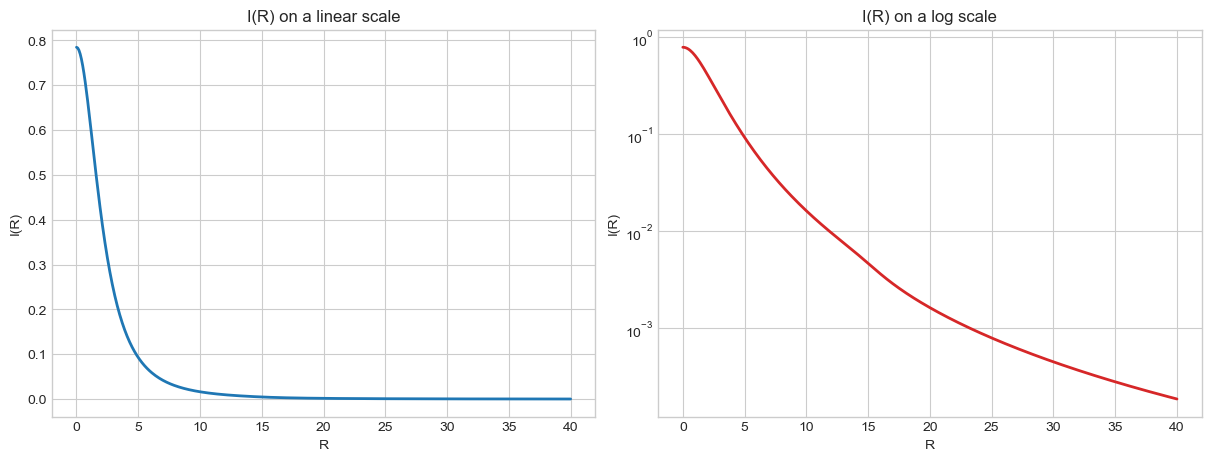

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

axes[0].plot(R_values, I_values, color="tab:blue", linewidth=2)
axes[0].set_title("I(R) on a linear scale")
axes[0].set_xlabel("R")
axes[0].set_ylabel("I(R)")

axes[1].semilogy(R_values, I_values, color="tab:red", linewidth=2)
axes[1].set_title("I(R) on a log scale")
axes[1].set_xlabel("R")
axes[1].set_ylabel("I(R)")

plt.show()


In [5]:
# Optional convergence spot-check.
# Re-run this cell after changing `n_cells` if you want to see how much the result moves.

def single_value(R, n_cells, cluster_power=2.0):
    X, Y, cell_area, inner_z = build_reduced_problem(
        x0, x1, y0, y1, Z, n_cells=n_cells, power=cluster_power
    )
    return compute_integral_curve(
        np.array([R], dtype=float), X, Y, cell_area, inner_z, Z, show_progress=False
    )[0]

for trial_n in [200, 300, 400, 500]:
    print(
        f"n_cells={trial_n:3d}  "
        f"I(0)={single_value(0.0, trial_n):.8f}  "
        f"I(10)={single_value(10.0, trial_n):.8f}"
    )


n_cells=200  I(0)=0.78325157  I(10)=0.01625627
n_cells=300  I(0)=0.78433067  I(10)=0.01626512
n_cells=400  I(0)=0.78474334  I(10)=0.01626848
n_cells=500  I(0)=0.78494609  I(10)=0.01627013


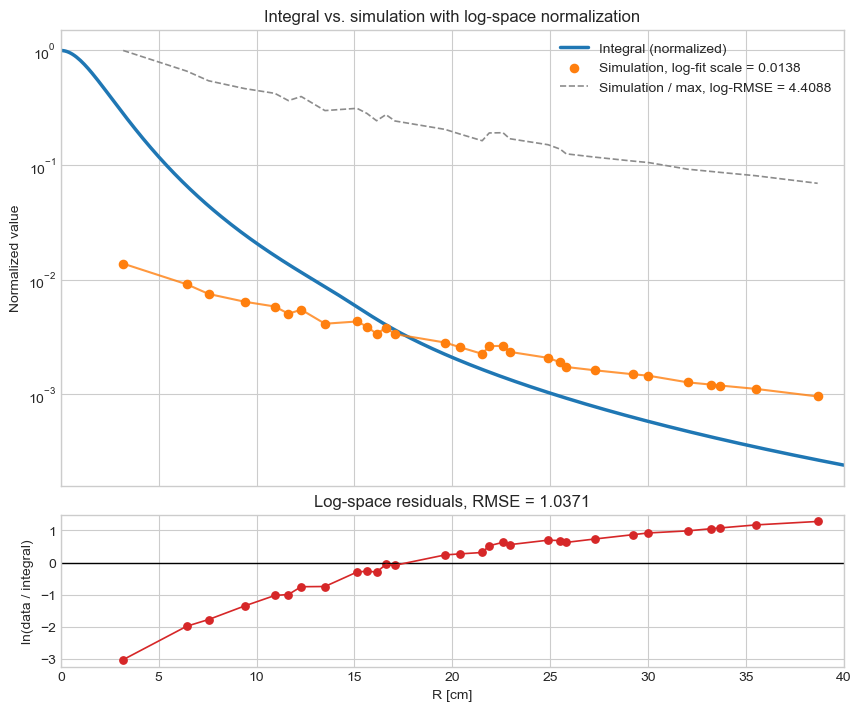

Best-fit scale factor for the simulation data: 0.013791
Log-space RMSE with best-fit scaling: 1.037051
Log-space RMSE with max normalization: 4.408774


,distance_cm,normalized_count,integral_norm,data_fit_norm,data_max_norm,log_integral_norm,log_data_fit_norm,log_data_max_norm,log_residual_fit,log_residual_max
0,3.186887,0.998706,0.281112,0.013773,1.000000,-1.269004,-4.285069,0.000000,-3.016065,1.269004
1,6.434769,0.659323,0.065652,0.009092,0.660177,-2.723383,-4.700316,-0.415247,-1.976933,2.308136
2,7.551904,0.542901,0.043903,0.007487,0.543604,-3.125779,-4.894603,-0.609534,-1.768824,2.516245
3,9.395810,0.464108,0.024596,0.006400,0.464709,-3.705168,-5.051413,-0.766344,-1.346245,2.938824
4,10.933035,0.421809,0.016159,0.005817,0.422356,-4.125283,-5.146977,-0.861908,-1.021694,3.263375


In [6]:
from io import StringIO

import pandas as pd

simulation_text = """distance_cm\tnormalized_count
0\t3.186887\t1.000000
1\t3.186887\t0.997412
2\t6.434769\t0.660190
3\t6.434769\t0.658456
4\t7.551904\t0.542942
5\t7.551904\t0.542859
6\t9.395810\t0.464774
7\t9.395810\t0.463441
8\t10.933035\t0.421641
9\t10.933035\t0.421977
10\t11.625672\t0.364395
11\t11.625672\t0.364764
12\t12.279302\t0.396147
13\t12.279302\t0.395461
14\t13.491896\t0.298515
15\t13.491896\t0.298148
16\t15.129648\t0.312220
17\t15.129648\t0.311992
18\t15.637495\t0.281530
19\t15.637495\t0.281943
20\t16.129360\t0.243032
21\t16.129360\t0.243427
22\t16.606663\t0.275488
23\t16.606663\t0.274375
24\t17.070625\t0.242013
25\t17.070625\t0.241930
26\t19.625398\t0.226316
27\t19.625398\t0.182557
28\t19.625398\t0.182419
29\t19.625398\t0.226328
30\t20.406035\t0.185454
31\t20.406035\t0.185972
32\t21.523969\t0.162701
33\t21.523969\t0.162809
34\t21.883927\t0.190054
35\t21.883927\t0.190477
36\t22.586639\t0.191666
37\t22.586639\t0.190680
38\t22.929920\t0.169557
39\t22.929920\t0.169315
40\t24.890385\t0.163164
41\t24.890385\t0.137417
42\t24.890385\t0.136991
43\t24.890385\t0.163215
44\t25.510415\t0.137646
45\t25.510415\t0.137148
46\t25.814846\t0.125090
47\t25.814846\t0.124950
48\t27.286100\t0.117352
49\t27.286100\t0.116584
50\t29.221674\t0.108223
51\t29.221674\t0.107923
52\t30.013018\t0.104934
53\t30.013018\t0.105006
54\t32.027820\t0.091684
55\t32.027820\t0.091862
56\t33.225085\t0.087597
57\t33.225085\t0.087827
58\t33.692080\t0.086232
59\t33.692080\t0.085944
60\t35.498680\t0.080302
61\t35.498680\t0.080740
62\t38.659168\t0.068997
63\t38.659168\t0.069293"""

simulation_df = pd.read_csv(
    StringIO(simulation_text),
    sep=r"\s+",
    skiprows=1,
    names=["sample_index", "distance_cm", "normalized_count"],
)

# Distances appear twice in the simulation block, so average them before comparing.
simulation_profile = (
    simulation_df.groupby("distance_cm", as_index=False)["normalized_count"]
    .mean()
    .sort_values("distance_cm")
)

integral_norm = I_values / I_values.max()
simulation_profile["integral_norm"] = np.interp(
    simulation_profile["distance_cm"], R_values, integral_norm
)

data_raw = simulation_profile["normalized_count"].to_numpy()
target = simulation_profile["integral_norm"].to_numpy()

# Fit the scale in log space: minimize ||log(a * data) - log(target)||^2.
best_fit_log_scale = np.mean(np.log(target) - np.log(data_raw))
best_fit_scale = np.exp(best_fit_log_scale)

simulation_profile["data_fit_norm"] = best_fit_scale * simulation_profile["normalized_count"]
simulation_profile["data_max_norm"] = (
    simulation_profile["normalized_count"] / simulation_profile["normalized_count"].max()
)
simulation_profile["log_integral_norm"] = np.log(simulation_profile["integral_norm"])
simulation_profile["log_data_fit_norm"] = np.log(simulation_profile["data_fit_norm"])
simulation_profile["log_data_max_norm"] = np.log(simulation_profile["data_max_norm"])
simulation_profile["log_residual_fit"] = (
    simulation_profile["log_data_fit_norm"] - simulation_profile["log_integral_norm"]
)
simulation_profile["log_residual_max"] = (
    simulation_profile["log_data_max_norm"] - simulation_profile["log_integral_norm"]
)

rmse_log_fit = np.sqrt(np.mean(simulation_profile["log_residual_fit"] ** 2))
rmse_log_max = np.sqrt(np.mean(simulation_profile["log_residual_max"] ** 2))

fig, axes = plt.subplots(
    2,
    1,
    figsize=(8.5, 7.0),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
    constrained_layout=True,
)

axes[0].semilogy(
    R_values,
    integral_norm,
    color="tab:blue",
    linewidth=2.5,
    label="Integral (normalized)",
)
axes[0].scatter(
    simulation_profile["distance_cm"],
    simulation_profile["data_fit_norm"],
    color="tab:orange",
    s=35,
    label=f"Simulation, log-fit scale = {best_fit_scale:.4f}",
    zorder=3,
)
axes[0].plot(
    simulation_profile["distance_cm"],
    simulation_profile["data_fit_norm"],
    color="tab:orange",
    linewidth=1.5,
    alpha=0.8,
)
axes[0].plot(
    simulation_profile["distance_cm"],
    simulation_profile["data_max_norm"],
    color="0.55",
    linestyle="--",
    linewidth=1.2,
    label=f"Simulation / max, log-RMSE = {rmse_log_max:.4f}",
)
axes[0].set_xlim(0.0, 40.0)
axes[0].set_ylabel("Normalized value")
axes[0].set_title("Integral vs. simulation with log-space normalization")
axes[0].legend()

axes[1].axhline(0.0, color="black", linewidth=1.0)
axes[1].scatter(
    simulation_profile["distance_cm"],
    simulation_profile["log_residual_fit"],
    color="tab:red",
    s=28,
)
axes[1].plot(
    simulation_profile["distance_cm"],
    simulation_profile["log_residual_fit"],
    color="tab:red",
    linewidth=1.2,
)
axes[1].set_xlabel("R [cm]")
axes[1].set_ylabel("ln(data / integral)")
axes[1].set_title(f"Log-space residuals, RMSE = {rmse_log_fit:.4f}")

plt.show()

print(f"Best-fit scale factor for the simulation data: {best_fit_scale:.6f}")
print(f"Log-space RMSE with best-fit scaling: {rmse_log_fit:.6f}")
print(f"Log-space RMSE with max normalization: {rmse_log_max:.6f}")

simulation_profile.head()
